In [2]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_csv("LogisticRegression.csv")
df.head()

,Release Year,County of Indictment,Gender,Age at Release,Return Status
0,2008,UNKNOWN,MALE,55,Not Returned
1,2008,ALBANY,MALE,16,Returned Parole Violation
2,2008,ALBANY,MALE,17,Not Returned
3,2008,ALBANY,MALE,17,Returned Parole Violation
4,2008,ALBANY,MALE,18,Not Returned


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299079 entries, 0 to 299078
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Release Year          299079 non-null  int64 
 1   County of Indictment  299079 non-null  object
 2   Gender                299079 non-null  object
 3   Age at Release        299079 non-null  int64 
 4   Return Status         299079 non-null  object
dtypes: int64(2), object(3)
memory usage: 11.4+ MB


In [6]:
df.shape

(299079, 5)

In [7]:
df.describe()

,Release Year,Age at Release
count,299079.000000,299079.000000
mean,2013.869416,36.063655
std,3.915258,11.197830
min,2008.000000,16.000000
25%,2010.000000,27.000000
50%,2014.000000,34.000000
75%,2017.000000,44.000000
max,2021.000000,100.000000


In [8]:
df.isnull().sum()

Release Year            0
County of Indictment    0
Gender                  0
Age at Release          0
Return Status           0
dtype: int64

In [9]:
import numpy as np

df["County of Indictment"] = (
    df["County of Indictment"]
    .replace("UNKNOWN", np.nan)
    .fillna(
        df["County of Indictment"]
        .replace("UNKNOWN", np.nan)
        .mode()[0]
    )
)

In [10]:
df.tail()

,Release Year,County of Indictment,Gender,Age at Release,Return Status
299074,2021,YATES,MALE,67,Not Returned
299075,2021,YATES,FEMALE,31,Not Returned
299076,2021,YATES,FEMALE,32,Not Returned
299077,2021,YATES,FEMALE,35,Not Returned
299078,2021,YATES,FEMALE,45,Not Returned


In [11]:
df = pd.get_dummies(df,columns=["Gender",'County of Indictment'],dtype=int,drop_first=True)
le = LabelEncoder()
df["Return Status"] = le.fit_transform(df["Return Status"])
df.head()

,Release Year,Age at Release,Return Status,Gender_MALE,County of Indictment_ALLEGANY,County of Indictment_BRONX,County of Indictment_BROOME,County of Indictment_CATTARAUGUS,County of Indictment_CAYUGA,County of Indictment_CHAUTAUQUA,...,County of Indictment_SULLIVAN,County of Indictment_TIOGA,County of Indictment_TOMPKINS,County of Indictment_ULSTER,County of Indictment_WARREN,County of Indictment_WASHINGTON,County of Indictment_WAYNE,County of Indictment_WESTCHESTER,County of Indictment_WYOMING,County of Indictment_YATES
0,2008,55,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2008,16,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2008,17,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2008,17,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,18,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
X=df.drop(columns=["Return Status"])
y=df['Return Status']

In [13]:
df["Return Status"].unique()

array([1, 2, 0])

In [14]:
y_train[y_train ==0] #17652
y_train[y_train ==1] #131120
y_train[y_train ==2] #60583

NameError: name 'y_train' is not defined

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=10000)
le = model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Accuracy
print("Accuracy :", accuracy_score(y_test, y_pred))

# Precision
print("Precision (Weighted):", precision_score(y_test, y_pred, average='weighted'))

# Recall
print("Recall (Weighted):", recall_score(y_test, y_pred, average='weighted'))

# F1 Score
print("F1 Score (Weighted):", f1_score(y_test, y_pred, average='weighted'))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)


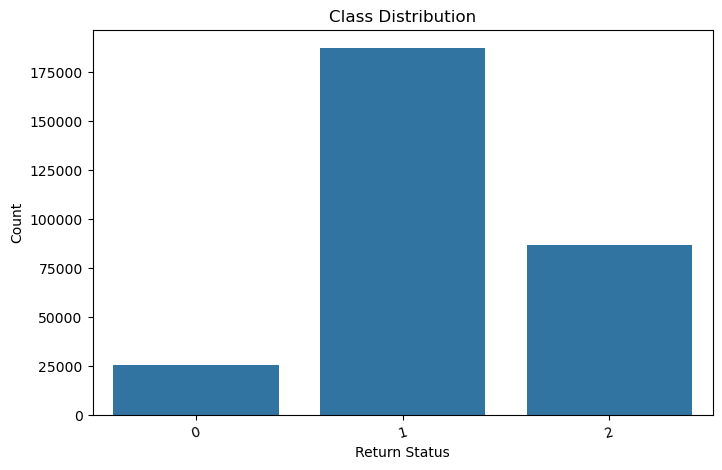

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Return Status', data=df)

plt.title("Class Distribution")
plt.xlabel("Return Status")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()